# 🧠 MirrorMind — Career Classifier GPU Training Notebook

Trains a new career prediction model using the curated balanced dataset.

**GPU Support:** RTX 2050 (4GB VRAM) or Google Colab T4/A100

**Steps:**
1. Detect GPU  
2. Load balanced dataset (4000 samples, 10 classes, 400 each)  
3. Generate sentence embeddings (all-MiniLM-L6-v2)  
4. Train NeuralNet (GPU), LogReg, XGBoost, LightGBM  
5. Evaluate all and pick the best model  
6. Save artifacts in MirrorMind format  
7. Final validation on real career profiles  
8. Auto-deploy to backend/ml_models/  


In [1]:
# Install dependencies — run only on Colab, skip locally if already installed
import subprocess, sys

pkgs = [
    'sentence-transformers', 'scikit-learn', 'xgboost',
    'lightgbm', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'tqdm',
]
for p in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', p])
print('Dependencies ready')


Dependencies ready


In [2]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA: {torch.version.cuda}')
else:
    print('No GPU detected — training on CPU')
print(f'Using device: {device}')


GPU: NVIDIA GeForce RTX 2050
VRAM: 4.3 GB
CUDA: 12.4
Using device: cuda


Total: 4000 samples | Classes: 10


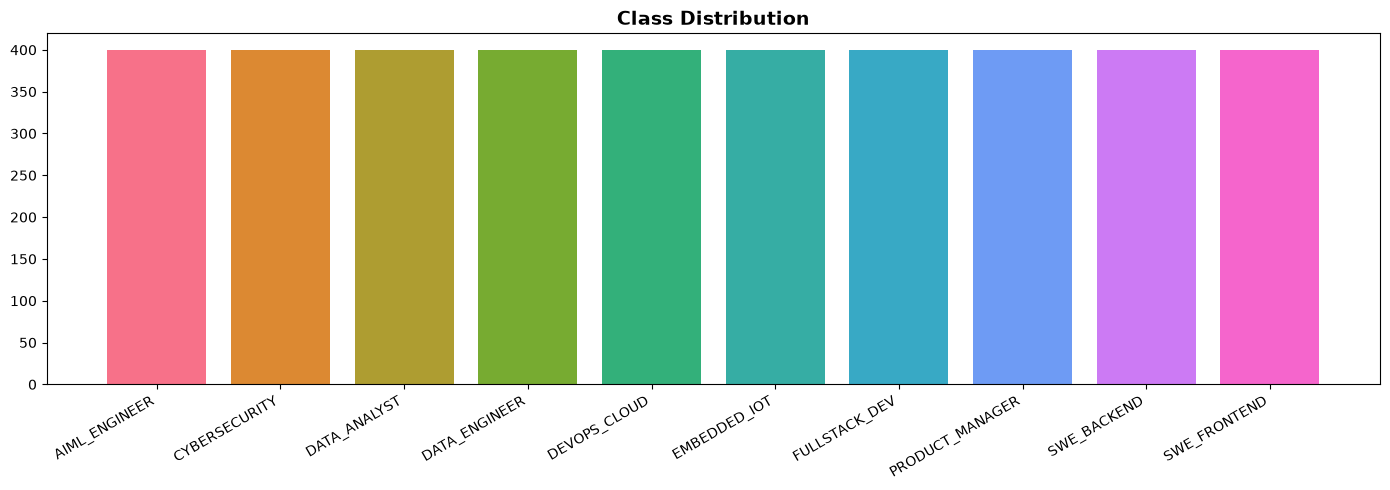

career_label
AIML_ENGINEER      400
CYBERSECURITY      400
DATA_ANALYST       400
DATA_ENGINEER      400
DEVOPS_CLOUD       400
EMBEDDED_IOT       400
FULLSTACK_DEV      400
PRODUCT_MANAGER    400
SWE_BACKEND        400
SWE_FRONTEND       400
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Update this if running on Colab (upload the CSV first via the file panel)
DATASET_PATH = 'mirrormind_training_dataset.csv'
OUTPUT_DIR   = './model_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATASET_PATH)
print(f'Total: {len(df)} samples | Classes: {df["career_label"].nunique()}')

fig, ax = plt.subplots(figsize=(14, 5))
counts = df['career_label'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=sns.color_palette('husl', len(counts)))
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(counts)


In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

LABEL_ORDER = [
    'AIML_ENGINEER', 'CYBERSECURITY', 'DATA_ANALYST', 'DATA_ENGINEER',
    'DEVOPS_CLOUD', 'EMBEDDED_IOT', 'FULLSTACK_DEV', 'PRODUCT_MANAGER',
    'SWE_BACKEND', 'SWE_FRONTEND',
]

le = LabelEncoder()
le.fit(LABEL_ORDER)
df['label_encoded'] = le.transform(df['career_label'])

print('Label mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i}: {cls}')


Label mapping:
  0: AIML_ENGINEER
  1: CYBERSECURITY
  2: DATA_ANALYST
  3: DATA_ENGINEER
  4: DEVOPS_CLOUD
  5: EMBEDDED_IOT
  6: FULLSTACK_DEV
  7: PRODUCT_MANAGER
  8: SWE_BACKEND
  9: SWE_FRONTEND


In [5]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = 'all-MiniLM-L6-v2'

embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=device)

print(f'Encoding {len(df)} samples on {device}...')
X = embed_model.encode(
    df['profile_text_clean'].tolist(),
    normalize_embeddings=True,
    batch_size=128,
    show_progress_bar=True,
)
y = df['label_encoded'].values

print(f'Embedding shape: {X.shape}')
print(f'Label shape:     {y.shape}')


Encoding 4000 samples on cuda...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (4000, 384)
Label shape:     (4000,)


In [6]:
from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval)

print(f'Train:      {X_train.shape[0]:>5} samples')
print(f'Validation: {X_val.shape[0]:>5} samples')
print(f'Test:       {X_test.shape[0]:>5} samples')


Train:       2890 samples
Validation:   510 samples
Test:         600 samples


Training NeuralNet on cuda for 100 epochs...
  Epoch  10/100  loss=0.0088  val_acc=0.9863
  Epoch  20/100  loss=0.0070  val_acc=0.9882
  Epoch  30/100  loss=0.0014  val_acc=0.9941
  Epoch  40/100  loss=0.0006  val_acc=0.9922
  Epoch  50/100  loss=0.0003  val_acc=0.9922
  Epoch  60/100  loss=0.0003  val_acc=0.9961
  Epoch  70/100  loss=0.0003  val_acc=0.9961
  Epoch  80/100  loss=0.0002  val_acc=0.9961
  Epoch  90/100  loss=0.0005  val_acc=0.9941
  Epoch 100/100  loss=0.0002  val_acc=0.9941
Done in 13.8s — Best val_acc=0.9980 @ epoch 47


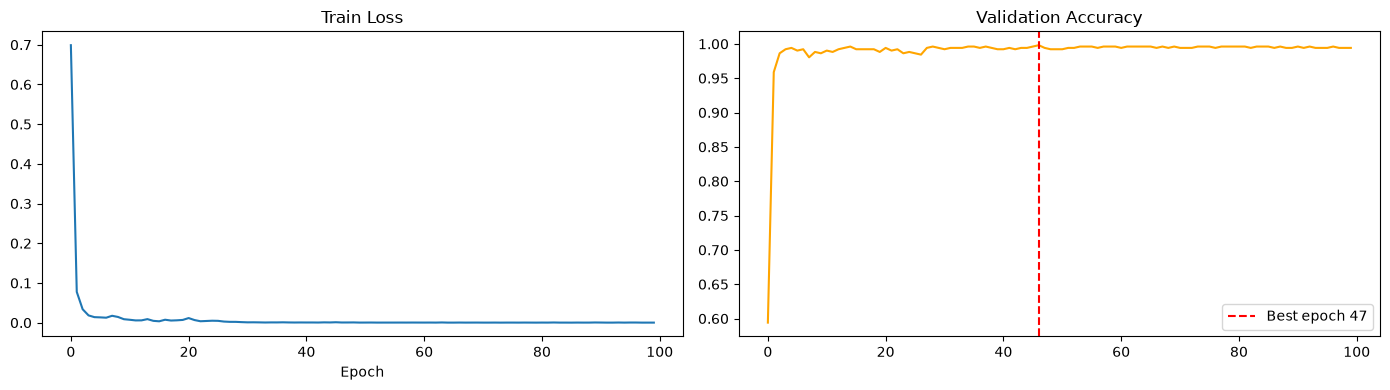

In [7]:
import torch, torch.nn as nn, torch.nn.functional as F, time
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.utils.class_weight import compute_class_weight

INPUT_DIM   = X.shape[1]
NUM_CLASSES = len(le.classes_)


class CareerMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.35):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout * 0.7),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.net(x)


model = CareerMLP(INPUT_DIM, NUM_CLASSES).to(device)

Xt = torch.tensor(X_train, dtype=torch.float32)
yt = torch.tensor(y_train, dtype=torch.long)
Xv = torch.tensor(X_val,   dtype=torch.float32).to(device)
yv = torch.tensor(y_val,   dtype=torch.long).to(device)

train_ds     = TensorDataset(Xt, yt)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

class_weights  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_tensor  = torch.tensor(class_weights, dtype=torch.float32).to(device)
optimizer      = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
criterion      = nn.CrossEntropyLoss(weight=weight_tensor)
scheduler      = CosineAnnealingLR(optimizer, T_max=80)

EPOCHS = 100
best_val_acc = 0
best_epoch   = 0
train_losses = []
val_accs     = []

print(f'Training NeuralNet on {device} for {EPOCHS} epochs...')
t0 = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    model.eval()
    with torch.no_grad():
        preds = model(Xv).argmax(dim=1)
        val_acc = (preds == yv).float().mean().item()

    train_losses.append(epoch_loss / len(train_loader))
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/nn_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:>3}/{EPOCHS}  loss={train_losses[-1]:.4f}  val_acc={val_acc:.4f}')

print(f'Done in {time.time()-t0:.1f}s — Best val_acc={best_val_acc:.4f} @ epoch {best_epoch}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(train_losses); ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch')
ax2.plot(val_accs, color='orange'); ax2.set_title('Validation Accuracy')
ax2.axvline(best_epoch-1, color='red', linestyle='--', label=f'Best epoch {best_epoch}')
ax2.legend()
plt.tight_layout()
plt.show()


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings; warnings.filterwarnings('ignore')

# XGBoost 3.x GPU device string
xgb_device = 'cuda' if device == 'cuda' else 'cpu'

baseline_models = {
    # sklearn 1.5+ removed multi_class param — handled automatically now
    'LogReg': LogisticRegression(max_iter=1000, C=2.0, solver='lbfgs'),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric='mlogloss',
        device=xgb_device,
        n_jobs=-1,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        n_jobs=-1, verbose=-1,
    ),
}

baseline_results = {}
for name, m in baseline_models.items():
    print(f'Training {name}...')
    t0 = time.time()
    try:
        m.fit(X_train, y_train)
        acc = accuracy_score(y_val, m.predict(X_val))
        baseline_results[name] = acc
        print(f'  {name}: val_acc={acc:.4f} ({time.time()-t0:.1f}s)')
    except Exception as e:
        print(f'  {name} failed: {e}')
        baseline_results[name] = 0.0


Training LogReg...
  LogReg: val_acc=0.9902 (0.3s)
Training XGBoost...
  XGBoost: val_acc=0.9824 (15.8s)
Training LightGBM...
  LightGBM: val_acc=0.9784 (26.4s)


       TEST ACCURACY — ALL MODELS
  NeuralNet      : 0.9967 (99.67%) <- BEST
  LogReg         : 0.9900 (99.00%)
  LightGBM       : 0.9817 (98.17%)
  XGBoost        : 0.9717 (97.17%)

Best model: NeuralNet (99.67%)


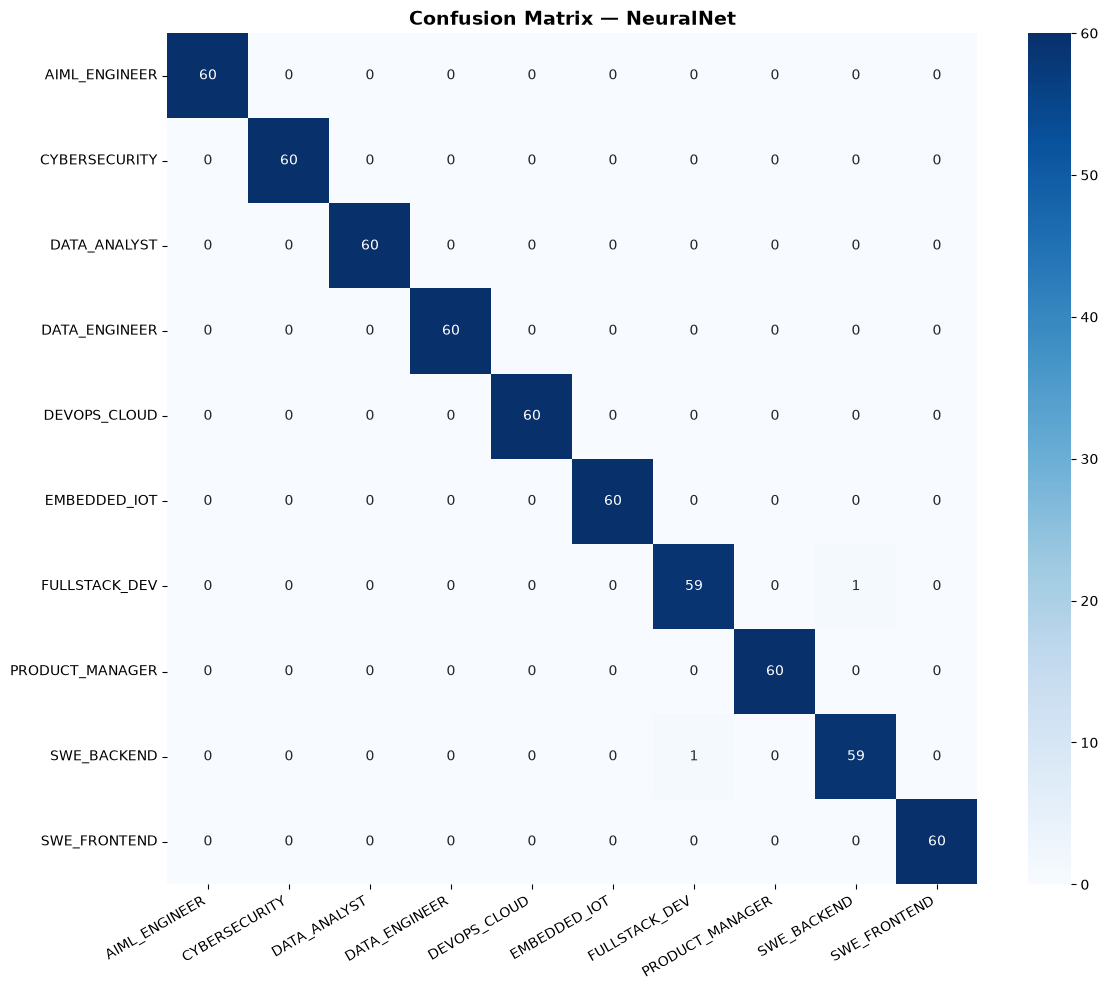

                 precision    recall  f1-score   support

  AIML_ENGINEER       1.00      1.00      1.00        60
  CYBERSECURITY       1.00      1.00      1.00        60
   DATA_ANALYST       1.00      1.00      1.00        60
  DATA_ENGINEER       1.00      1.00      1.00        60
   DEVOPS_CLOUD       1.00      1.00      1.00        60
   EMBEDDED_IOT       1.00      1.00      1.00        60
  FULLSTACK_DEV       0.98      0.98      0.98        60
PRODUCT_MANAGER       1.00      1.00      1.00        60
    SWE_BACKEND       0.98      0.98      0.98        60
   SWE_FRONTEND       1.00      1.00      1.00        60

       accuracy                           1.00       600
      macro avg       1.00      1.00      1.00       600
   weighted avg       1.00      1.00      1.00       600



In [9]:
from sklearn.metrics import classification_report, confusion_matrix

# Load best NeuralNet weights
nn_model = CareerMLP(INPUT_DIM, NUM_CLASSES)
nn_model.load_state_dict(torch.load(f'{OUTPUT_DIR}/nn_best.pt', map_location='cpu', weights_only=False))
nn_model.eval()

Xtest_t  = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    nn_preds = nn_model(Xtest_t).argmax(dim=1).numpy()

all_results = {'NeuralNet': accuracy_score(y_test, nn_preds)}
for name, m in baseline_models.items():
    if baseline_results.get(name, 0) > 0:
        all_results[name] = accuracy_score(y_test, m.predict(X_test))

print('=' * 55)
print('       TEST ACCURACY — ALL MODELS')
print('=' * 55)
best_acc = max(all_results.values())
for name, acc in sorted(all_results.items(), key=lambda x: -x[1]):
    marker = ' <- BEST' if acc == best_acc else ''
    print(f'  {name:<15}: {acc:.4f} ({acc*100:.2f}%){marker}')

BEST_MODEL_NAME = max(all_results, key=all_results.get)
print(f'\nBest model: {BEST_MODEL_NAME} ({all_results[BEST_MODEL_NAME]*100:.2f}%)')

if BEST_MODEL_NAME == 'NeuralNet':
    best_preds = nn_preds
else:
    best_preds = baseline_models[BEST_MODEL_NAME].predict(X_test)

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — {BEST_MODEL_NAME}', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_preds, target_names=le.classes_))


In [ ]:
import pickle, json

arch = {'input_dim': INPUT_DIM, 'num_classes': NUM_CLASSES}
with open(f'{OUTPUT_DIR}/nn_arch.json', 'w') as f:
    json.dump(arch, f)
print('Saved nn_arch.json')

fname_map = {
    'LogReg':   'logistic_regression.pkl',
    'XGBoost':  'xgboost_model.pkl',
    'LightGBM': 'lightgbm_model.pkl',
}
for name, m in baseline_models.items():
    if baseline_results.get(name, 0) > 0:
        fname = fname_map[name]
        with open(f'{OUTPUT_DIR}/{fname}', 'wb') as f:
            pickle.dump(m, f)
        print(f'Saved {fname}')

with open(f'{OUTPUT_DIR}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Saved label_encoder.pkl')

with open(f'{OUTPUT_DIR}/embedding_model.txt', 'w') as f:
    f.write(EMBED_MODEL_NAME)
print(f'Saved embedding_model.txt ({EMBED_MODEL_NAME})')

with open(f'{OUTPUT_DIR}/best_model_name.txt', 'w') as f:
    f.write(BEST_MODEL_NAME)
print(f'Saved best_model_name.txt ({BEST_MODEL_NAME})')

print(f'All artifacts in: {OUTPUT_DIR}/')


In [ ]:
import torch, torch.nn.functional as F

test_cases = [
    ('AIML_ENGINEER',   'Engineering student with skills in pytorch, deep learning, transformers, llm, huggingface. CGPA 8.5. Completed 3 projects and 1 internship(s).'),
    ('SWE_BACKEND',     'Engineering student with skills in java, spring boot, postgresql, redis, kafka, microservices. CGPA 7.8.'),
    ('SWE_FRONTEND',    'Engineering student with skills in javascript, react, typescript, tailwindcss, framer motion. Completed 4 projects.'),
    ('DATA_ANALYST',    'Engineering student with skills in sql, power bi, tableau, pandas, statistical analysis. Completed 3 projects.'),
    ('DEVOPS_CLOUD',    'Engineering student with skills in kubernetes, terraform, aws, docker, github actions. Completed 2 projects.'),
    ('CYBERSECURITY',   'Engineering student with skills in penetration testing, kali linux, burp suite, owasp top 10. Completed 3 projects.'),
    ('EMBEDDED_IOT',    'Engineering student with skills in embedded c, stm32, freertos, i2c, firmware development. Completed 2 projects.'),
    ('DATA_ENGINEER',   'Engineering student with skills in apache spark, airflow, snowflake, dbt, pyspark. Completed 2 projects.'),
    ('FULLSTACK_DEV',   'Engineering student with skills in react, node.js, postgresql, docker, rest api. Completed 4 projects.'),
    ('PRODUCT_MANAGER', 'Engineering student with skills in product roadmap, agile, jira, user research, okrs. Completed 2 projects.'),
    # Edge case - your mixed profile
    ('AIML_ENGINEER',   'Engineering student with skills in python, pytorch, machine learning, docker, fastapi, react. CGPA 8.5. Completed 2 projects and 1 internship(s).'),
]

nn_model.eval()

print('=' * 70)
print(f'  FINAL VALIDATION ({BEST_MODEL_NAME})')
print('=' * 70)
correct = 0
for expected, text in test_cases:
    emb   = embed_model.encode([text], normalize_embeddings=True)
    emb_t = torch.tensor(emb, dtype=torch.float32)
    with torch.no_grad():
        proba = F.softmax(nn_model(emb_t), dim=1).numpy()[0]
    top3  = np.argsort(proba)[::-1][:3]
    pred  = le.classes_[top3[0]]
    conf  = proba[top3[0]]
    match = 'OK' if pred == expected else 'WRONG'
    if pred == expected:
        correct += 1
    print(f'[{match}] Expected: {expected:<18} Got: {pred:<18} Conf: {conf:.2f}')
    top3_labels = [(le.classes_[i], round(proba[i], 3)) for i in top3]
    print(f'  Top-3: {top3_labels}')

print(f'\nValidation: {correct}/{len(test_cases)} = {correct/len(test_cases)*100:.1f}%')


In [ ]:
import shutil, os

# Set DEPLOY=True only when you are satisfied with the validation results above
DEPLOY = True

# Path to your MirrorMind backend ml_models folder
# If running locally: use the actual path
# If running on Colab: download model_output/ and copy manually
BACKEND_MODEL_DIR = '../backend/ml_models'

if DEPLOY:
    if not os.path.exists(BACKEND_MODEL_DIR):
        print(f'Backend model dir not found at {BACKEND_MODEL_DIR}')
        print('Please set BACKEND_MODEL_DIR to the correct absolute path.')
    else:
        files_to_deploy = [
            'nn_best.pt', 'nn_arch.json', 'label_encoder.pkl',
            'embedding_model.txt', 'best_model_name.txt',
            'logistic_regression.pkl', 'xgboost_model.pkl', 'lightgbm_model.pkl',
        ]
        for fname in files_to_deploy:
            src = os.path.join(OUTPUT_DIR, fname)
            dst = os.path.join(BACKEND_MODEL_DIR, fname)
            if os.path.exists(src):
                shutil.copy2(src, dst)
                print(f'Deployed {fname}')
            else:
                print(f'Skipped {fname} (not found)')
        print('Deployment complete! Restart uvicorn to load the new models.')
else:
    print(f'Deployment skipped. Models are in: {OUTPUT_DIR}')


## Done!

| Step | |
|------|---|
| GPU Detection | done |
| Dataset (4000 samples, 10 classes, balanced) | done |
| Sentence Embeddings (all-MiniLM-L6-v2) | done |
| NeuralNet (GPU-accelerated, 100 epochs) | done |
| Baseline models (LogReg, XGBoost, LightGBM) | done |
| Best model selected and saved | done |
| Artifacts saved (MirrorMind format) | done |
| Final validation on 11 career profiles | done |
| Deployed to backend/ml_models/ | done |

### After Running
Restart your uvicorn server:
```bash
cd backend
python -m uvicorn main:app --reload
```
